<a href="https://colab.research.google.com/github/gnlearn/Bird-Species-Image-Recognition-with-Advanced-Neural-Networks/blob/main/RL_value_iteration_frozen_lake_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Importing the right library**
> you need to import gymnasium and other useful modules

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import clear_output
import numpy as np
import pdb
from numpy.random import default_rng
import time
my_random_number_generator = default_rng()

##**Creating an instance of FrozenLake Environment**

> Create an environment by defining a controlled setup. You can use four symbols to configure the environment:
>> **S** for Start tile

>> **F** for frozen tile

>> **H** for a tile with a hole

>> **G** for Goal tile

> Let’s make the move through the environment by controlled way

#**Non-slippery (deterministic) FrozenLake**
> Instantiate an environment object for FrozenLake


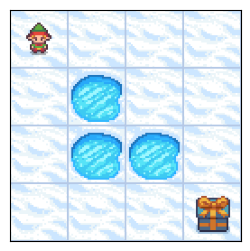

In [2]:
plt.figure(figsize=(3,3))
nrows = 4
ncols = 4

'''
custom_map = [
    "SFFF",
    "FFFF",
    "FFHF",
    "FFFG"
]
'''

custom_map = [
    "SFFF",
    "FHFF",
    "FHHF",
    "FFFG"
]
env     = gym.make("FrozenLake-v1", desc=custom_map, is_slippery=False, render_mode='rgb_array')
state   = env.reset()[0] #observation, info = env.reset(seed=42)[0]


# display the current environment
clear_output(wait=True)
img = env.render()
plt.xticks([])
plt.yticks([])
plt.imshow(img)
plt.show()
time.sleep(0.1)


env.close()

In [3]:
# FrozenLake is a known and fully defined MDP model. Hence you can explore the transition
# probabilities from each state along with its all possible action
state = 0
action = 1
P = env.unwrapped.P
print(P[state])
#state_action_tuple = P[state][action]
#print(state_action_tuple)

{0: [(1.0, 0, 0, False)], 1: [(1.0, 4, 0, False)], 2: [(1.0, 1, 0, False)], 3: [(1.0, 0, 0, False)]}


In [4]:
state = 0
action = 0 # left
state_action_tuple = P[state][action]
for (prob, next_state, reward, done) in state_action_tuple:
    print(f"prob={prob:.2f}, next_state={next_state}, reward={reward}, done={done}")

prob=1.00, next_state=0, reward=0, done=False


In [5]:
state = 0
action = 1 # down
state_action_tuple = P[state][action]
for (prob, next_state, reward, done) in state_action_tuple:
    print(f"prob={prob:.2f}, next_state={next_state}, reward={reward}, done={done}")

prob=1.00, next_state=4, reward=0, done=False


In [6]:
state = 0
action = 2 # right
state_action_tuple = P[state][action]
for (prob, next_state, reward, done) in state_action_tuple:
    print(f"prob={prob:.2f}, next_state={next_state}, reward={reward}, done={done}")

prob=1.00, next_state=1, reward=0, done=False


#**Convention of the state space (or also referred to as observation space)**
Let's assume our frozenLake environment has `nrows=4` and `ncols=4`. In other words, it is a `4×4` environment.

Each 2D position in the grid corresponds to a state of the environment. Thus, every state represents a position of the form `(cur_row, cur_col)`. Gymnasium internally uses a linearized (1D) representation of this 2D position—that is, a single integer value. The state is computed as:

> `state = cur_row * ncols + cur_col`

For example, if the agent is at position `(cur_row = 2, cur_col = 2)` in a `4×4` FrozenLake environment:

> `state = 2 * 4 + 2 = 10`

Similarly, if the agent’s goal is at position `(cur_row = 3, cur_col = 3)` in the same `4×4` environment:

> `state = 3 * 4 + 3 = 15`

It always returns an integer between `0` to `nrow * ncol - 1`.

In [7]:
print('total number of states:', env.observation_space.n)
random_state = env.observation_space.sample()
print('random state:', random_state)

total number of states: 16
random state: 6


#**Convert it into a 2D space using the inverse formula**


In [8]:
cur_row = random_state // ncols # integer division
cur_col = random_state % ncols  # modulo operation
print(f"2D state representation=({cur_row},{cur_col})")

2D state representation=(1,2)


##**Some supporting utility functions**

In [9]:
def print_pi_opt(Pi_opt, custom_map, nrows, ncols):
    #Pi_opt_2d  = np.zeros((nrows, ncols)) # create optimal Policy-table of size 4x4
    Pi_opt_2d = [['.' for _ in range(ncols)] for _ in range(nrows)]
    for i in range(len(Pi_opt)):
        cur_row = i // ncols
        cur_col = i % ncols
        if custom_map[cur_row][cur_col] != 'H' and custom_map[cur_row][cur_col] != 'G':
            if Pi_opt[i] == 0:
                Pi_opt_2d[cur_row][cur_col] = 'L'
            elif Pi_opt[i] == 1:
                Pi_opt_2d[cur_row][cur_col] = 'D'
            elif Pi_opt[i] == 2:
                Pi_opt_2d[cur_row][cur_col] = 'R'
            elif Pi_opt[i] == 3:
                Pi_opt_2d[cur_row][cur_col] = 'U'

    for k in range(len(Pi_opt_2d)):
        print(Pi_opt_2d[k])



In [10]:
def print_optimal_value_table(V_opt_table, custom_map, nrows, ncols):
    V_opt_2d_table = [[0.0 for _ in range(ncols)] for _ in range(nrows)]
    for k in range(len(V_opt_table)):
        row_index = k//ncols
        col_index = k%ncols
        V_opt_2d_table[row_index][col_index] =  float(V_opt_table[k])

    for i in range(len(V_opt_2d_table)):
        for j in range(len(V_opt_2d_table[i])):
            print(f"{float(V_opt_2d_table[i][j]):5.2f}",end="")
        print()


In [11]:
def print_optimal_q_table(Q_new, custom_map, nrows, ncols):
    for i in range(len(Q_new)):
        print("\n[", end="")
        for j in range(len(Q_new[i])):
            print(f"{Q_new[i,j]:5.2f}, ", end="")
        print("]")

In [12]:
def get_valid_state_list(custom_map):
    state_list = []
    state_counter = 0
    for i in range(len(custom_map)):
        cur_row = custom_map[i]
        for j in range(len(cur_row)):
            if cur_row[j] != 'H' and cur_row[j] != 'G':
                state_list.append(state_counter)
            state_counter +=1
    return state_list

print(get_valid_state_list(custom_map))

[0, 1, 2, 3, 4, 6, 7, 8, 11, 12, 13, 14]


##**Determining the sizes of V and Q tables**

> How many entries will there be in the `V table`?

> How many entries will there be in the `Q table`?

In [13]:
# v-function table since the observations are discrete and actions are discrete
V_new                   = np.zeros(env.observation_space.n) # create V-table of size 64x1
print("\n[", end="")
for i in range(len(V_new)):
    print(f"{V_new[i]:5.2f}, ", end="")
print("]\n")


[ 0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00, ]



In [14]:
# v-function table since the observations are discrete and actions are discrete
Q_new                   = np.zeros((env.observation_space.n, env.action_space.n)) # create Q-table of size 64x4

for i in range(len(Q_new)):
    print("\n[", end="")
    for j in range(len(Q_new[i])):
        print(f"{Q_new[i,j]:5.2f}, ", end="")
    print("]")


[ 0.00,  0.00,  0.00,  0.00, ]

[ 0.00,  0.00,  0.00,  0.00, ]

[ 0.00,  0.00,  0.00,  0.00, ]

[ 0.00,  0.00,  0.00,  0.00, ]

[ 0.00,  0.00,  0.00,  0.00, ]

[ 0.00,  0.00,  0.00,  0.00, ]

[ 0.00,  0.00,  0.00,  0.00, ]

[ 0.00,  0.00,  0.00,  0.00, ]

[ 0.00,  0.00,  0.00,  0.00, ]

[ 0.00,  0.00,  0.00,  0.00, ]

[ 0.00,  0.00,  0.00,  0.00, ]

[ 0.00,  0.00,  0.00,  0.00, ]

[ 0.00,  0.00,  0.00,  0.00, ]

[ 0.00,  0.00,  0.00,  0.00, ]

[ 0.00,  0.00,  0.00,  0.00, ]

[ 0.00,  0.00,  0.00,  0.00, ]


#**Exercise#1: Finding the Optimal Policy of 4x4 non-slippery (deterministic)Frozen Lake using the Value Iteration Algorithm**
You need to implement the value iteration algorithm here. You may take inspiration from the code I shared during the lecture, where I demonstrated the value iteration algorithm on a simple MDP involving a dice game. The link is provided [here](https://github.com/alimoorreza/CS143-sp26-notes/blob/main/value_iteration_on_simple_MDP.ipynb)

> Complete multiple iterations of updating agent movement from each grid position

> Apply Bellman update rule during each iteration for all the states

In [17]:
custom_map = [
    "SFFF",
    "FHFF",
    "FHHF",
    "FFFG"
]
env                     = gym.make("FrozenLake-v1", desc=custom_map, is_slippery=False, render_mode="rgb_array")
state                   = env.reset(seed=42)[0]


# initialize value-iteration parameters
gamma               = 1.0
epsilon             = 1e-8
isImproving         = True
t                   = 0
TOTAL_ITERATION     = 1000

# initialize v-function table since the observations are discrete and actions are discrete
V_new            = np.zeros(env.observation_space.n)
# initialize q-function table since the observations are discrete and actions are discrete
Q_new            = np.zeros((env.observation_space.n, env.action_space.n))

# initialize optimal policy table that will save the optimal action for each state
Pi_opt                   = np.zeros(env.observation_space.n, dtype=int)

# FrozenLake is a known and fully defined MDP model. Hence you can explore the transition
# probabilities from each state along with its all possible action
P = env.unwrapped.P

# your value iteration loop (either while loop or a for loop starts from here)
while isImproving and t < TOTAL_ITERATION:

    V_old            = V_new.copy()
    isImproving      = False

    for state_idx in range(env.observation_space.n):


        for action_idx in range(env.action_space.n):

            q_state_action = 0.0


            state_action_tuple = P[state_idx][action_idx]

            for (prob, next_state, reward, done) in state_action_tuple:

                if done:
                    q_state_action += prob * reward
                else:
                    q_state_action += prob * (reward + gamma * V_old[next_state])

            Q_new[state_idx, action_idx] = q_state_action


        new_value_for_state = np.max(Q_new[state_idx, :])


        if abs(new_value_for_state - V_old[state_idx]) > epsilon:
            isImproving = True
        V_new[state_idx] = new_value_for_state


        Pi_opt[state_idx] = np.argmax(Q_new[state_idx, :])

    t += 1

print(f"{t} iterations.")

print("\nOptimal Value Table:")
print_optimal_value_table(V_new, custom_map, nrows, ncols)

print("\nOptimal Policy:")
print_pi_opt(Pi_opt, custom_map, nrows, ncols)

env.close()

7 iterations.

Optimal Value Table:
 1.00 1.00 1.00 1.00
 1.00 0.00 1.00 1.00
 1.00 0.00 0.00 1.00
 1.00 1.00 1.00 0.00

Optimal Policy:
['L', 'L', 'L', 'L']
['L', '.', 'R', 'L']
['L', '.', '.', 'D']
['L', 'L', 'L', '.']


##**Inference:**
Once you obtain the optimal policy, you can observe the agent’s navigation using the following inference code.
> Testing the learned optimal policy

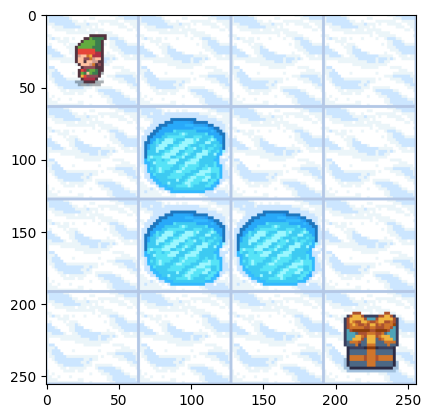

KeyboardInterrupt: 

In [18]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time


#terminated = True # when it either reaches the goal or falls in a hole
#truncated = True # when it takes more than 200 actions

plt.figure(figsize=(4,4))
custom_map = [
    "SFFF",
    "FHFF",
    "FHHF",
    "FFFG"
]
env     = gym.make("FrozenLake-v1", desc=custom_map, is_slippery=False, render_mode='rgb_array')


# initial state
terminated = False
truncated = False
state = env.reset()[0]

while not terminated and not truncated:

    # sample one of the 4 actions: 0:LEFT, 1:DOWN, 2:RIGHT, 3:UP
    # EXPLOITATION OF THE OPTIMAL POLICY
    action = Pi_opt[state]

    new_state, reward, terminated, truncated, info = env.step(action)


    # display the current environment
    clear_output(wait=True)
    img = env.render()
    plt.imshow(img)
    plt.show()
    time.sleep(0.5)
    state = new_state


env.close()

#**Exercise#2: Finding the Optimal Policy of 4x4 Slippery (stochastic) Frozen Lake using the Value Iteration Algorithm**

> Now try your value iteration algorithm again on the slippery version of the FrozenLake environment. You may copy and paste your solution from Exercise 1, but initialize the environment by setting the `is_slippery` flag to `True`.



In [ ]:
custom_map = [
    "SFFF",
    "FHFF",
    "FHHF",
    "FFFG"
]
env     = gym.make("FrozenLake-v1", desc=custom_map, is_slippery=True, render_mode='rgb_array')
state                   = env.reset()[0] #observation, info = env.reset(seed=42)[0]

# your code
# ...
# ...
# ...

##**Inference:**
> Testing the learned policy

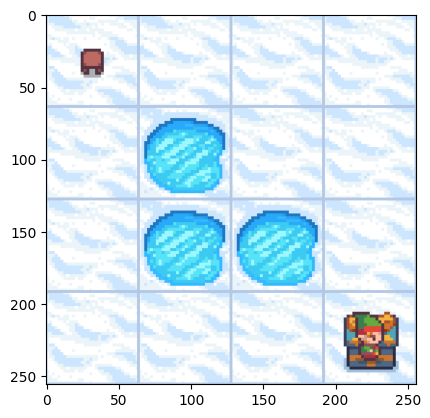

In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time


#terminated = True # when it either reaches the goal or falls in a hole
#truncated = True # when it takes more than 200 actions

plt.figure(figsize=(4,4))
custom_map = [
    "SFFF",
    "FHFF",
    "FHHF",
    "FFFG"
]
env     = gym.make("FrozenLake-v1", desc=custom_map, is_slippery=True, render_mode='rgb_array')


# initial state
terminated = False
truncated = False
state = env.reset()[0]

while not terminated and not truncated:

    # sample one of the 4 actions: 0:LEFT, 1:DOWN, 2:RIGHT, 3:UP
    # EXPLOITATION OF THE OPTIMAL POLICY
    action = Pi_opt[state]

    new_state, reward, terminated, truncated, info = env.step(action)


    # display the current environment
    clear_output(wait=True)
    img = env.render()
    plt.imshow(img)
    plt.show()
    time.sleep(0.5)
    state = new_state


env.close()

#**Exercise#3: Finding the Optimal Policy of 8x8 non-slippery (deterministic) Frozen Lake using the Value Iteration Algorithm**

> Here is an 8x8 controlled map of the frozen lake.

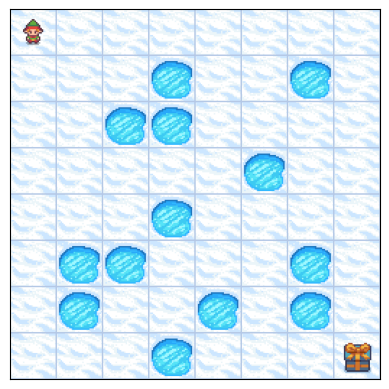

In [ ]:
custom_map = [
    "SFFFFFFF",
    "FFFHFFHF",
    "FFHHFFFF",
    "FFFFFHFF",
    "FFFHFFFF",
    "FHHFFFHF",
    "FHFFHFHF",
    "FFFHFFFG",
]
env     = gym.make("FrozenLake-v1", desc=custom_map, is_slippery=False, render_mode='rgb_array') # alternate render_mode: render_mode='human' or render_mode='ansi'
state   = env.reset()
# display the current environment
clear_output(wait=True)
img = env.render()
plt.xticks([])
plt.yticks([])
plt.imshow(img)
plt.show()
time.sleep(0.1)

env.close()


> Now try your value iteration algorithm again on the non-slippery version of the FrozenLake environment again like Exercise#1 but the state-space here is larger ie, 64. You may copy and paste your solution from Exercise#1.


In [ ]:
# your code
# ...
# ...
# ...

##**Inference:**
> Testing the learned policy

In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time


custom_map = [
    "SFFFFFFF",
    "FFFHFFHF",
    "FFHHFFFF",
    "FFFFFHFF",
    "FFFHFFFF",
    "FHHFFFHF",
    "FHFFHFHF",
    "FFFHFFFG",
]
env     = gym.make("FrozenLake-v1", desc=custom_map, is_slippery=False, render_mode='rgb_array') # alternate render_mode: render_mode='human' or render_mode='ansi'
state   = env.reset()

# initial state
terminated = False
truncated = False
state = env.reset()[0]

while not terminated and not truncated:

    # sample one of the 4 actions: 0:LEFT, 1:DOWN, 2:RIGHT, 3:UP
    # EXPLOITATION OF THE OPTIMAL POLICY
    action = Pi_opt[state]

    new_state, reward, terminated, truncated, info = env.step(action)


    # display the current environment
    clear_output(wait=True)
    img = env.render()
    plt.imshow(img)
    plt.show()
    time.sleep(0.5)
    state = new_state


env.close()

Complete and run three instances of Frozen Lakes (Exercises#1-3) with value iteration algorithm. Make sure the run the inferences after finishing the value iteration so that I can you trace the path the agent is taking on the maps.

> You should complete the exercises and then write some observations.




| **Problem Instance**     | **#of iterations during training** | **time took** | **# of actions during inference** |
|---------------|--------------------|----------------|----------------|
| 4x4 non-slippery FL|                    |                   |                |
| 4x4 slippery FL|                    |                   |                |
| 8x8 non-slippery FL|                    |                   |                |


Also include a text/Markdown cell that addresses the following points:

1. Explain the basis on which the path costs are computed.

2. Specify how different values of the discount factor $\gamma$ affected your value iteration algorithm. You should try at least one of the three instances of FrozenLake and make a note of your observations.

3. Provide a brief description of the modifications made to the code.

4. Discuss any differences observed—using the comparative table above—in the computed routes, execution time, number of nodes expanded, and related metrics.


### Grading

The assignment is worth 8 points. Partial credit (up to 6 points) will be awarded if any of the required components are incomplete.

* Up to 6 points: You made code changes that demonstrate a reasonable attempt to complete the implementation of the **value iteration algorithm on FrozenLake** instances.

* Up to 7 points: You tuned the discount factor $\gamma$ at least once in one of the three value iteration experiments.

* Up to 8 points: You filled out the comparative analysis table above with all entries. You implemented a working version of the value iteration algorithm on all three FrozenLake instances and recorded the corresponding results in the table above.


### Turning it in

Share the notebook in the same way you did for Project 4.
